# 1. Import Required Libraries

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import zipfile
import os
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# 2. Download Dataset via Kaggle API

In [6]:
import kagglehub

path = kagglehub.dataset_download("tongpython/cat-and-dog")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'cat-and-dog' dataset.
Path to dataset files: /kaggle/input/cat-and-dog


# 3. Define Paths and Data Constants

In [7]:
train_dir = '/kaggle/input/cat-and-dog/training_set/training_set'
test_dir = '/kaggle/input/cat-and-dog/test_set/test_set'

IMG_SIZE = (150, 150)
BATCH_SIZE = 32

# 4. Data Preprocessing and Augmentation

In [8]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

Found 8005 images belonging to 2 classes.
Found 2023 images belonging to 2 classes.


# 5. Build CNN Model Architecture

In [9]:
model = models.Sequential([
    # Convolutional Block 1
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    layers.MaxPooling2D((2, 2)),

    # Convolutional Block 2
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Convolutional Block 3
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Dense Layers
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,481 (18.42 MB)

 Trainable params: 4,828,481 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

# 6. Train the Model

In [10]:
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=test_generator
)

Epoch 1/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 405s 2s/step - accuracy: 0.5839 - loss: 0.6737 - val_accuracy: 0.6782 - val_loss: 0.6315
Epoch 2/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 414s 2s/step - accuracy: 0.6563 - loss: 0.6135 - val_accuracy: 0.7054 - val_loss: 0.5599
Epoch 3/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 399s 2s/step - accuracy: 0.6924 - loss: 0.5916 - val_accuracy: 0.7370 - val_loss: 0.5377
Epoch 4/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 458s 2s/step - accuracy: 0.7157 - loss: 0.5548 - val_accuracy: 0.7583 - val_loss: 0.4979
Epoch 5/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 399s 2s/step - accuracy: 0.7339 - loss: 0.5313 - val_accuracy: 0.7514 - val_loss: 0.4900
Epoch 6/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 398s 2s/step - accuracy: 0.7523 - loss: 0.5110 - val_accuracy: 0.7865 - val_loss: 0.4584
Epoch 7/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 406s 2s/step - accuracy: 0.7565 - loss: 0.5010 - val_accuracy: 0.8047 - val_loss: 0.4382
Epoch 8/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 393s 2s/step - accuracy: 0.7721 - loss: 0.4793 - val_accu

# 7. Evaluate Model and Plot Results

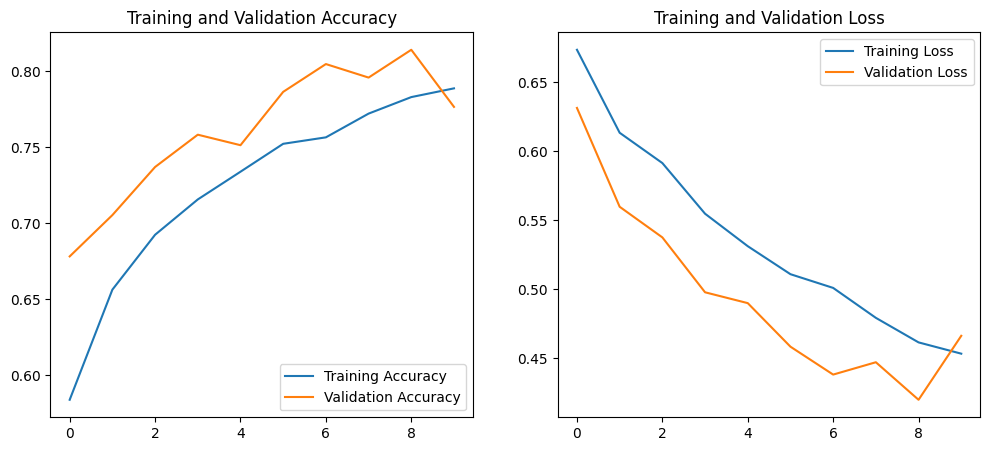

64/64 ━━━━━━━━━━━━━━━━━━━━ 36s 549ms/step
Classification Report:
              precision    recall  f1-score   support

        Cats       0.90      0.62      0.74      1011
        Dogs       0.71      0.93      0.81      1012

    accuracy                           0.78      2023
   macro avg       0.81      0.78      0.77      2023
weighted avg       0.81      0.78      0.77      2023



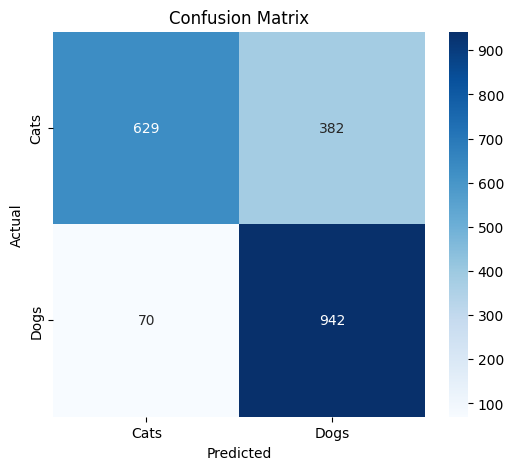

In [11]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

plt.show()

Y_pred = model.predict(test_generator)
y_pred = np.where(Y_pred > 0.5, 1, 0)

print('Classification Report:')
print(classification_report(test_generator.classes, y_pred, target_names=['Cats', 'Dogs']))

cm = confusion_matrix(test_generator.classes, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Cats', 'Dogs'], yticklabels=['Cats', 'Dogs'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()